In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Harmonic Oscillation

### Background
In this exercise, you will implement the phase-space solution for a harmonic oscillator, as described in Chapter 5.  
This system represents frictionless oscillatory motion, like an ideal mass-spring system.

### Tasks
1. Examine the given parameters and initial conditions of the system.

2. Investigate how the dynamic matrix A is constructed from the physical parameters.

3. Analyze the eigenvalues and eigenvectors of the system.
   - What do the imaginary eigenvalues indicate about the behavior of the system?
   - How are the eigenvectors related to the oscillation?

4. Run the simulation and observe the position and velocity plots.

5. **Warning**: Test **other initial conditions** (e.g., try x₀ = 0, v₀ = 0.1) and check whether the results are robust.



[0.+1.j 0.-1.j]

[[0.70710678+0.j         0.70710678-0.j        ]
 [0.        +0.70710678j 0.        -0.70710678j]]


c:\Program Files\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Program Files\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


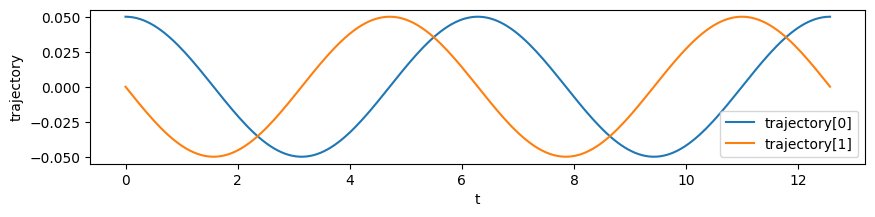

In [2]:
# Parameters 
m = 1
k = 1
ω = np.sqrt(k/m)
t=0
# Initial conditions
x0 = 0.1
v0 = 0.
A=np.array([[0,1],
            [-ω **2,0]], dtype= float)
λ, Q =np.linalg.eig(A)
S=np.array([x0,v0])
print(λ)
print()
print (Q)

#S=c1*(q1)**(λ*t)-c2*(q2)**(λ*t)
c = np.linalg.solve(Q,S)

def simulation(λ, Q,c,t):
    n=c.size
    x=0
    for i in range(n):
        x=c[i]*Q[:,i].reshape(-1,1)*np.exp(λ[i]*t)
    return x

#lets write the code for t
t=np.linspace(0,4*np.pi,200)
trajectory=simulation(λ, Q,c,t)
x_t=trajectory[0]
y_t=trajectory[1]

plt.figure(figsize=[10,2])
plt.plot(t,x_t,label="trajectory[0]")
plt.plot(t,y_t,label="trajectory[1]")
plt.xlabel("t")
plt.ylabel("trajectory")
plt.legend()
plt.show()



(<Figure size 800x500 with 2 Axes>, <Axes: xlabel='t $[s]$', ylabel='x $[m]$'>)

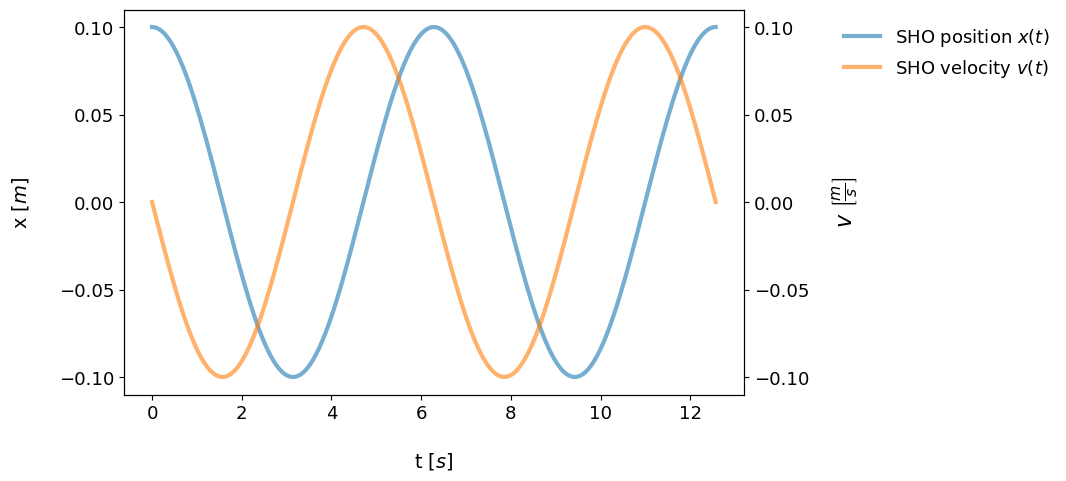

In [ ]:
# Parameters 
m = 1.
k = 1.
ω = np.sqrt(k/m)

# Initial conditions
x0 = 0.1
v0 = 0.
##
## Your code
A=np.array([[0,1],
           [-ω**2,0]],dtype=float)
s=np.array([[x0,v0]])
λ, Q=np.linalg.eig(A)
print(λ)
print(Q)

def simulation(t,λ,Q,c):
    n=c.size
    x=0
    for i in range(n):
        x=c[i]*Q[:,i].reshape(n,1)*np.exp(λ[i]*t)
        return x

t=np.linspace(0,4*np.pi,200)
trajectory=simulation(λ, Q,c,t)
x_t=trajectory[0]
y_t=trajectory[1]

plt.figure(figsize=[10,2])
plt.plot(t,x_t,label="trajectory[0]")
plt.plot(t,y_t,label="trajectory[1]")
plt.xlabel("t")
plt.ylabel("trajectory")
plt.legend()
plt.show()





## 2. Damped Oscillation

### Background
We now examine oscillatory systems with damping (friction), which leads to energy dissipation over time.  
The damping coefficient μ determines whether the system is underdamped, critically damped, or overdamped.




### Tasks for the Underdamped Case
1. Investigate how the dynamic matrix now contains a damping term.

2. Run the simulation with μ = 0.5 and observe the behavior.

3. Analyze the eigenvalues:
   - How do they differ from those of the harmonic oscillator?
   - What information is provided by the real parts of the eigenvalues?

4. **TODO**: Present the decrease of the oscillation amplitude over time in a plot.

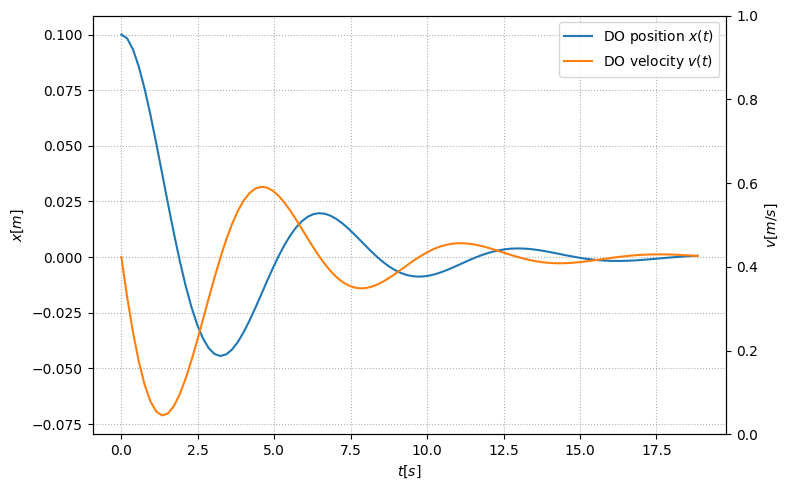

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 1.
k = 1.
mu = .5
w = np.sqrt(k/m)
b_ = -mu/m

# Initial conditions
x0 = 0.1
v0 = 0.

##
## Your code
##
s = np.array([x0, v0])
A = np.array([[0, 1],
              [-w**2, b_]])

l, Q = np.linalg.eig(A)
c = np.linalg.solve(Q, s)

t = np.linspace(0, 6*np.pi, 100)
lp = np.real(l)
s_ = 0
s_1 = 0

for i in range(c.size):
    s_ += c[i]*Q[:,i].reshape(c.size, 1)*np.exp(l[i]*t)

#for i in range(c.size):
    #s_1 += np.real(c[i])*np.real(Q[:,i]).reshape(c.size, 1)*np.exp(lp[i]*t)

labels = ['DO position $x(t)$', 'DO velocity $v(t)$']
fig, ax = plt.subplots(layout='tight', figsize=(8,5))

ax.plot(t, np.real(s_).T, label=labels)
#ax.plot(t, s_1[0], linewidth=0.7, label='decrease of oscillation amplitude over time')

ax.grid(ls=':')
ax.set_xlabel('$t[s]$')

ax2 = ax.twinx()
ax.set_ylabel('$x[m]$')
ax2.set_ylabel('$v[m/s]$')

ax.legend()
plt.show()


### Tasks for the Overdamped Case

1. Run the simulation with μ = 3.0.

2. Compare the behavior with the underdamped case.

3. Examine the eigenvalues — why are they purely real in this case?

4. **TODO**: Implement a parameter study that shows the transition between different damping regimes by plotting several curves with different μ values (e.g., `μ = [0.5, 2.0, 2.5]`) in the same diagram.



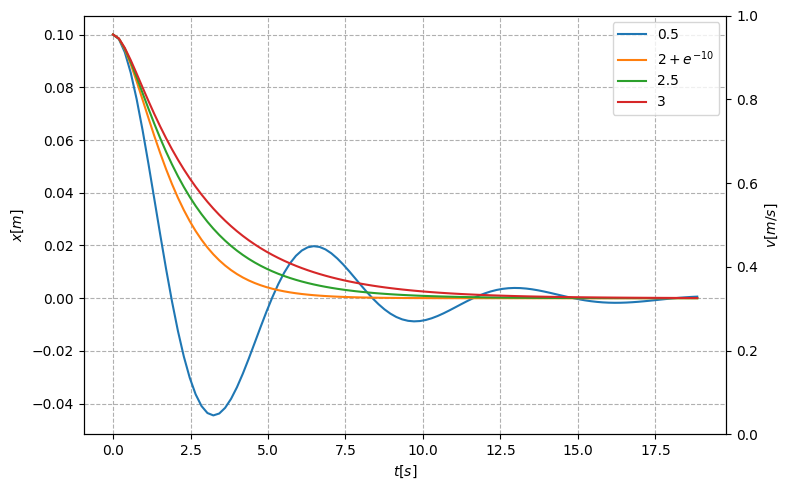

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 1.
k = 1.
u = 3.
mu = [0.5, 2. + np.e**(-10), 2.5, 3.]
w = np.sqrt(k/m)
# b_ = -u/m  # Commented out in original
b_ = [-u_val/m for u_val in mu]

# Initial conditions
x0 = 0.1
v0 = 0.

##
## Your code
##

s = np.array([x0, v0])
# Creating the system matrices for each damping value
A = [np.array([[0, 1], [-w**2, b_val]]) for b_val in b_]
l, Q = np.linalg.eig(A)

# Solving for the constants based on initial conditions
c = np.linalg.solve(Q, s)
t = np.linspace(0, 6 * np.pi, 100)
s_ = [0, 0, 0, 0]

for j in range(4):
    for i in range(c[j].size):
        # Calculating state vector as a sum of modes
        s_[j] = s_[j] + c[j][i] * Q[j][:, i].reshape(c[0].size, 1) * np.exp(l[j][i] * t)

# Plotting
fig, ax = plt.subplots(layout='tight', figsize=(8, 5))
labels = ['0.5', r'$2 + e^{-10}$', '2.5', '3']

for j in range(4):
    # Plotting the real part of the displacement (index 0 of the state vector)
    ax.plot(t, np.real(s_[j][0]), label=labels[j])

ax.grid(ls='--')
ax.set_xlabel(r'$t [s]$')
ax.set_ylabel(r'$x [m]$')

# Secondary axis for velocity (though not plotted in the loop above, 
# it is initialized in the screenshot)
ax2 = ax.twinx()
ax2.set_ylabel(r'$v [m/s]$')

ax.legend()
plt.show()


### Tasks for the Critically Damped Case

1. Run the simulation with μ = 2·√(k/m).

2. **Analysis Question**: This case theoretically represents a defective matrix (repeated eigenvalues). Why does the simulation still work?

3. Examine the eigenvalues and eigenvectors carefully.

4. **TODO**: Add a small perturbation to the damping coefficient (e.g., μ = 2·√(k/m) + 1e-10) and compare the results with the exactly critically damped case.



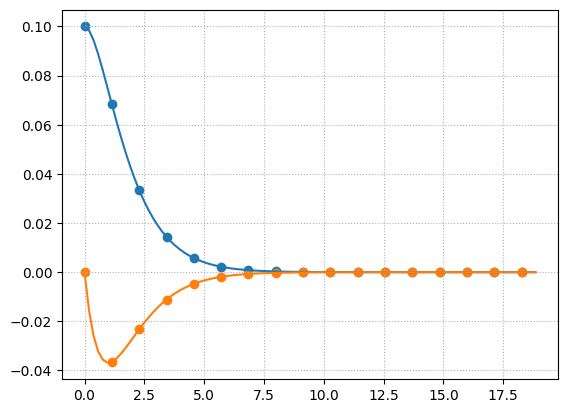

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 1.
k = 1.
w = np.sqrt(k/m)
mu = 2*np.sqrt(k/m) + np.exp(-10)
b_ = mu/(m)

# Initial conditions
x0 = 0.1
v0 = 0.

## Your code
A = np.array([[0, 1],
              [-w**2, -b_]])
s0 = np.array([x0, v0])

l, Q = np.linalg.eig(A)
c = np.linalg.solve(Q, s0)
t = np.linspace(0, 6*np.pi, 100)

s_ = 0
for i in range(l.size):
    s_ += c[i] * Q[:, i].reshape(c.size, 1) * np.exp(l[i] * t)

plt.plot(t, np.real(s_[0]))
plt.plot(t, np.real(s_[1]))
plt.grid(ls=':')

# Analytic model
x1 = v0 + x0 * w
t1 = t[::6]
x = (x0 + x1 * t1) * np.exp(-w * t1)
v = (x1 - x0 * w - x1 * w * t1) * np.exp(-w * t1)

plt.scatter(t1, x)
plt.scatter(t1, v)

plt.show()


In [11]:
np.set_printoptions(precision=16)
Q

array([[ 0.7071067835514547, -0.7071067788216405],
       [-0.7071067788216403,  0.7071067835514546]])

### Parameter Study (Additional Exercise)

1. **TODO**: Implement a parameter study that shows the transition between different damping regimes by plotting several *x(t)* curves with different μ values (e.g., `μ = [0.5, 2.0, 2.5]`) in the same diagram.

2. **Discussion**: Explain how numerical errors in floating-point arithmetic sometimes help rather than hinder simulations.


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\hm-cesi01te\AppData\Local\Temp\ipykernel_12296\4192609998.py:9: SyntaxWarning: invalid escape sequence '\m'
  labels = ['$\mu = 0.5$', '$\mu = 2.0$', '$\mu = 3.5$']
C:\Users\hm-cesi01te\AppData\Local\Temp\ipykernel_12296\4192609998.py:9: SyntaxWarning: invalid escape sequence '\m'
  labels = ['$\mu = 0.5$', '$\mu = 2.0$', '$\mu = 3.5$']
C:\Users\hm-cesi01te\AppData\Local\Temp\ipykernel_12296\4192609998.py:9: SyntaxWarning: invalid escape sequence '\m'
  labels = ['$\mu = 0.5$', '$\mu = 2.0$', '$\mu = 3.5$']


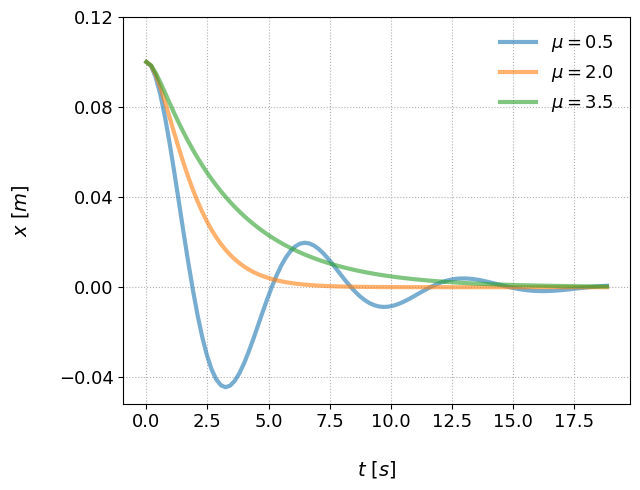

In [6]:
mu = [0.5, 2.0 + 1e-10, 3.5]
b_ = [-mu/m for mu in mu]

# Initial conditions
x0 = 0.1
v0 = 0.
x0 = np.array([x0, v0])
positions = []
labels = ['$\mu = 0.5$', '$\mu = 2.0$', '$\mu = 3.5$']
##
## Your code
s = x0
A = [np.array([[0, 1], 
              [-w**2, b_ii]]) for b_ii in b_]

l, Q = np.linalg.eig(A)

c = np.linalg.solve(Q, s)
t = np.linspace(0, 6*np.pi, 100)
fig, ax = plt.subplots(layout='tight', figsize=(6.5, 5))

s_ = [0, 0, 0]
for j in range(3):
    for i in range(c[0].size):
        s_[j] = s_[j] + c[j][i]*Q[j][:,i].reshape(c[0].size, 1)*np.exp(l[j][i]*t)
        #print(c[i])

    #Plotting results
    ax.plot(t, np.real(s_[j][0]), label=labels[j], alpha=0.6, lw=3)
ax.grid(ls=':')


#Adjusting Labels
ax.set_xlabel(r'$t \ [s]$', fontsize=14, labelpad=20)
ax.set_ylabel(r'$x \ [m]$', fontsize=14, labelpad=20)
ax.set_yticks(ax.get_yticks()[1::2])
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13, frameon=False);


## 3. Chemical Network

### Background
In this exercise, you will simulate a linear chain of chemical reactions.

This demonstrates how the same framework of linear dynamics can be applied to completely different physical systems.

### Tasks

1. Consider the reaction network:

    A $\stackrel{k_1=5.1}{\underset{k_2=5.0}{\rightleftharpoons}}$ B $\stackrel{k_3=0.2}{\longrightarrow}$ C $\stackrel{k_4=0.1}{\longrightarrow}$ D

    and examine how it is represented as a system of linear differential equations.

2. Run the simulation and observe the concentration profiles.

3. Analyze the eigenvalues of the system:

    - Which eigenvalue corresponds to the steady-state solution?

    - Which eigenvalues correspond to fast vs. slow processes in the reaction?

4. **Investigation of numerical stability**:
    - Remove the small perturbation from k₂ (set it exactly to 5.0) and observe what happens.
    - Explain why the simulation becomes unstable.
    - Determine the minimal perturbation required to maintain stability.

5. **Challenge**: Modify the reaction network by adding a backward reaction from D to C, and analyze how this affects the steady-state concentrations.


(4,)


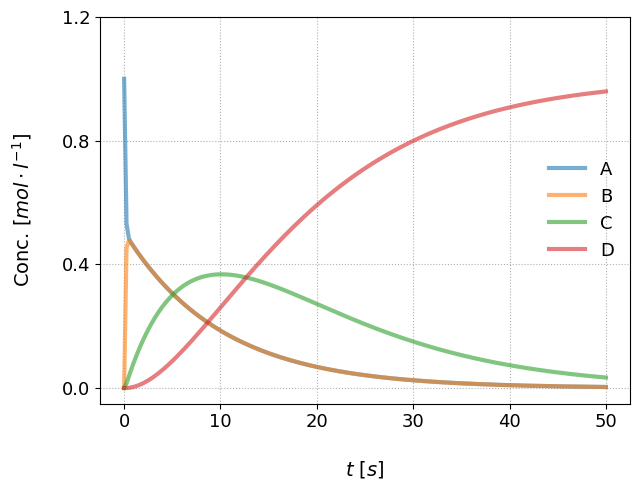

In [9]:
# Rate constants
k1 = 5.1
k2 = 5. + 1e-7
k3 = .2
k4 = .1
k5 = .0

# Initial concentrations in mol l^(-1)
A0, B0, C0, D0 = 1.+1e-10, 0+1e-10, 0, 0
s = np.array([A0, B0, C0, D0]).T

##
## Your code
A = np.array([[-k1, k2, 0, 0],
              [k1, -(k2+k3), 0, 0],
              [0, k3, -k4, k5],
              [0, 0, k4, -k5]])

l, Q = np.linalg.eig(A)
c = np.linalg.solve(Q, s)
print(c.shape)
t = np.linspace(0, 50, 201)

s_ = 0
for i in range(c.size):
    s_ += c[i]*Q[:, i].reshape(c.size, 1)*np.exp(l[i]*t)

# Plotting results
fig, ax = plt.subplots(layout='tight', figsize=(6.5, 5))
ax.plot(t, s_.T, label=['A', 'B', 'C', 'D'], alpha=0.6, lw=3)

# Adjusting Labels
ax.set_xlabel(r'$t \ [s]$', fontsize=14, labelpad=20)
ax.set_ylabel(r'Conc. $\left[mol \cdot l^{-1}\right]$', fontsize=14, labelpad=20)
ax.set_yticks(ax.get_yticks()[1::2])
ax.tick_params(axis='both', labelsize=13)
ax.grid(ls=':')
ax.legend(fontsize=13, frameon=False);
